Hola buenos días

In [7]:
!pip install "numpy<2.0" --force-reinstall

     ---------------------------------------- 0.0/61.0 kB ? eta -:--:--
     ------ --------------------------------- 10.2/61.0 kB ? eta -:--:--
     ------------------- ------------------ 30.7/61.0 kB 325.1 kB/s eta 0:00:01
     -------------------------------------- 61.0/61.0 kB 540.4 kB/s eta 0:00:00
   ---------------------------------------- 0.0/15.5 MB ? eta -:--:--
   ---------------------------------------- 0.2/15.5 MB 5.6 MB/s eta 0:00:03
   - -------------------------------------- 0.6/15.5 MB 7.9 MB/s eta 0:00:02
   -- ------------------------------------- 1.0/15.5 MB 9.5 MB/s eta 0:00:02
   --- ------------------------------------ 1.5/15.5 MB 10.5 MB/s eta 0:00:02
   ----- ---------------------------------- 1.9/15.5 MB 9.5 MB/s eta 0:00:02
   ------ --------------------------------- 2.5/15.5 MB 9.8 MB/s eta 0:00:02
   ------ --------------------------------- 2.7/15.5 MB 9.4 MB/s eta 0:00:02
   -------- ------------------------------- 3.1/15.5 MB 9.5 MB/s eta 0:00:02
   -----

  You can safely remove it manually.
  You can safely remove it manually.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
streamlit 1.51.0 requires pandas<3,>=1.4.0, but you have pandas 3.0.3 which is incompatible.


c:\Users\mateo\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:23: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\mateo\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


¡Gráfica generada con ajuste ponderado y errores de parámetros!


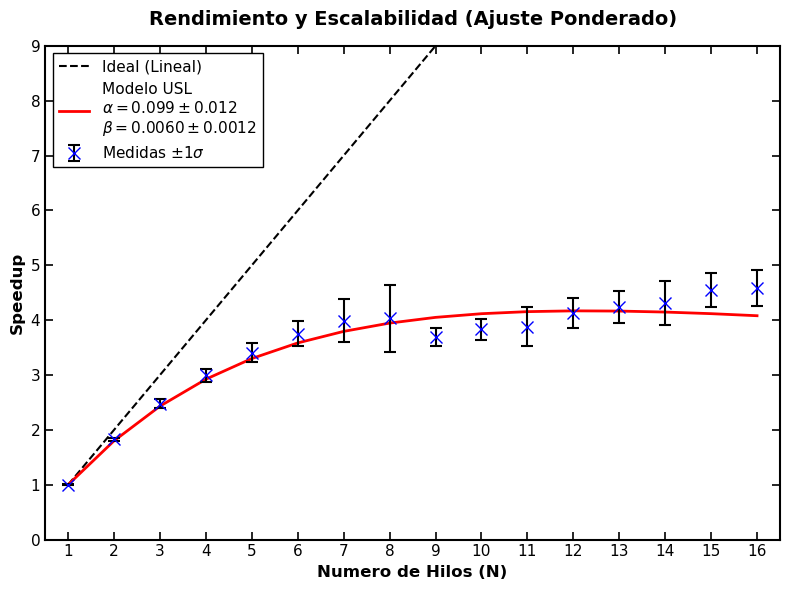

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def funcion_usl(n, alpha, beta):
    return n / (1 + alpha * (n - 1) + beta * n * (n - 1))

def main():
    try:
        df = pd.read_csv('amdahl_estadistico.csv')
    except FileNotFoundError:
        print("Error: No se encontró 'amdahl_estadistico.csv'.")
        return

    hilos = df['Hilos'].values
    t_medios = df['Tiempo_Medio_ms'].values
    t_std = df['Desviacion_ms'].values

    T1_medio = t_medios[0]
    T1_std = t_std[0]

    # Cálculos estadísticos y de Speedup
    speedup_medio = T1_medio / t_medios
    speedup_err = speedup_medio * np.sqrt((T1_std / T1_medio)**2 + (t_std / t_medios)**2)

    # ====================================================================
    # MAGIA ESTADÍSTICA: Ajuste Ponderado (Chi-cuadrado)
    # sigma=speedup_err: Los puntos con menos error pesan más en el ajuste
    # absolute_sigma=True: Los errores están en las mismas unidades que Y
    # ====================================================================
    popt, pcov = curve_fit(funcion_usl, hilos, speedup_medio, 
                           sigma=speedup_err, absolute_sigma=True, 
                           bounds=(0.0, 1.0))
    
    alpha_est, beta_est = popt
    
    # Extraemos los errores de los parámetros desde la matriz de covarianza
    errores_parametros = np.sqrt(np.diag(pcov))
    alpha_err, beta_err = errores_parametros

    speedup_ideal = hilos  
    speedup_usl = funcion_usl(hilos, alpha_est, beta_est)

    # ==========================================
    # ESTILO GNUPLOT MEJORADO (Fondo blanco, caja negra)
    # ==========================================
    plt.style.use('default') # Base limpia
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Configuración de los bordes (Spines) negros y gruesos
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)

    # Ticks hacia adentro y en todos los bordes (Puro Gnuplot)
    ax.tick_params(direction='in', top=True, right=True, length=6, width=1.2, labelsize=11)

    # Dibujamos las curvas
    ax.plot(hilos, speedup_ideal, 'k--', linewidth=1.5, label='Ideal (Lineal)')
    
    # Ahora la leyenda incluye el valor ± su error
    etiqueta_usl = f'Modelo USL\n$\\alpha = {alpha_est:.3f} \\pm {alpha_err:.3f}$\n$\\beta = {beta_est:.4f} \\pm {beta_err:.4f}$'
    ax.plot(hilos, speedup_usl, 'r-', linewidth=2, label=etiqueta_usl)
    
    # Datos con barras de error
    ax.errorbar(hilos, speedup_medio, yerr=speedup_err, fmt='bx', 
                markersize=8, capsize=4, capthick=1.5, elinewidth=1.5, 
                ecolor='black', label='Medidas $\\pm 1\\sigma$')

    # Textos
    ax.set_xlabel('Numero de Hilos (N)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Speedup', fontsize=12, fontweight='bold')
    ax.set_title('Rendimiento y Escalabilidad (Ajuste Ponderado)', fontsize=14, fontweight='bold', pad=15)
    
    ax.set_xticks(hilos)
    ax.set_xlim(0.5, max(hilos) + 0.5)
    ax.set_ylim(0, max(speedup_ideal)/2 + 1)
    
    # Leyenda estilo caja cerrada clásica
    ax.legend(loc='upper left', frameon=True, edgecolor='black', 
              fancybox=False, framealpha=1.0, fontsize=11)
    
    plt.tight_layout()
    plt.savefig('grafica_usl_gnuplot_corregida2.png', dpi=300)
    print("¡Gráfica generada con ajuste ponderado y errores de parámetros!")
    plt.show()

if __name__ == '__main__':
    main()

¡Gráfica generada con ajuste ponderado y errores de parámetros!


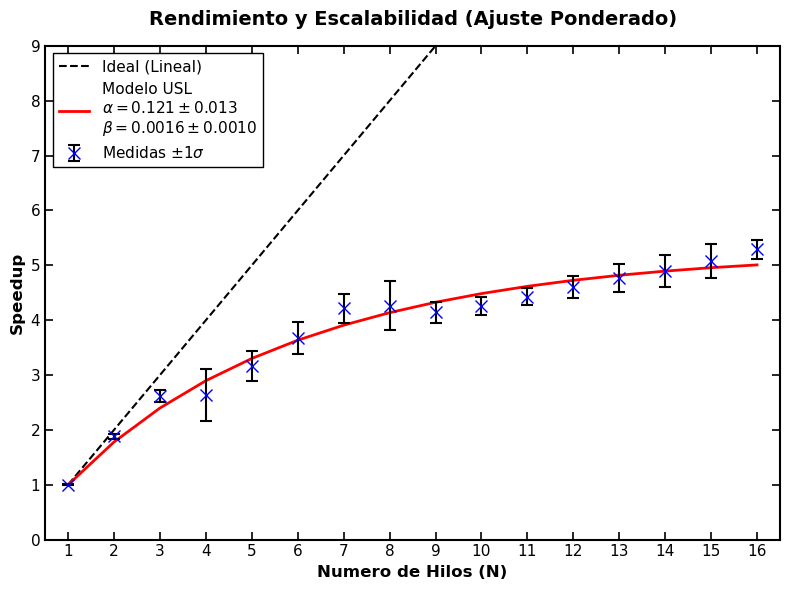

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def funcion_usl(n, alpha, beta):
    return n / (1 + alpha * (n - 1) + beta * n * (n - 1))

def main():
    try:
        df = pd.read_csv('amdahl_estadistico_cartera_grande.csv')
    except FileNotFoundError:
        print("Error: No se encontró 'amdahl_estadistico_curvas_tipos.csv'.")
        return

    hilos = df['Hilos'].values
    t_medios = df['Tiempo_Medio_ms'].values
    t_std = df['Desviacion_ms'].values

    T1_medio = t_medios[0]
    T1_std = t_std[0]

    # Cálculos estadísticos y de Speedup
    speedup_medio = T1_medio / t_medios
    speedup_err = speedup_medio * np.sqrt((T1_std / T1_medio)**2 + (t_std / t_medios)**2)

    # ====================================================================
    # MAGIA ESTADÍSTICA: Ajuste Ponderado (Chi-cuadrado)
    # sigma=speedup_err: Los puntos con menos error pesan más en el ajuste
    # absolute_sigma=True: Los errores están en las mismas unidades que Y
    # ====================================================================
    popt, pcov = curve_fit(funcion_usl, hilos, speedup_medio, 
                           sigma=speedup_err, absolute_sigma=True, 
                           bounds=(0.0, 1.0))
    
    alpha_est, beta_est = popt
    
    # Extraemos los errores de los parámetros desde la matriz de covarianza
    errores_parametros = np.sqrt(np.diag(pcov))
    alpha_err, beta_err = errores_parametros

    speedup_ideal = hilos  
    speedup_usl = funcion_usl(hilos, alpha_est, beta_est)

    # ==========================================
    # ESTILO GNUPLOT MEJORADO (Fondo blanco, caja negra)
    # ==========================================
    plt.style.use('default') # Base limpia
    fig, ax = plt.subplots(figsize=(8, 6))
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    # Configuración de los bordes (Spines) negros y gruesos
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(1.5)

    # Ticks hacia adentro y en todos los bordes (Puro Gnuplot)
    ax.tick_params(direction='in', top=True, right=True, length=6, width=1.2, labelsize=11)

    # Dibujamos las curvas
    ax.plot(hilos, speedup_ideal, 'k--', linewidth=1.5, label='Ideal (Lineal)')
    
    # Ahora la leyenda incluye el valor ± su error
    etiqueta_usl = f'Modelo USL\n$\\alpha = {alpha_est:.3f} \\pm {alpha_err:.3f}$\n$\\beta = {beta_est:.4f} \\pm {beta_err:.4f}$'
    ax.plot(hilos, speedup_usl, 'r-', linewidth=2, label=etiqueta_usl)
    
    # Datos con barras de error
    ax.errorbar(hilos, speedup_medio, yerr=speedup_err, fmt='bx', 
                markersize=8, capsize=4, capthick=1.5, elinewidth=1.5, 
                ecolor='black', label='Medidas $\\pm 1\\sigma$')

    # Textos
    ax.set_xlabel('Numero de Hilos (N)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Speedup', fontsize=12, fontweight='bold')
    ax.set_title('Rendimiento y Escalabilidad (Ajuste Ponderado)', fontsize=14, fontweight='bold', pad=15)
    
    ax.set_xticks(hilos)
    ax.set_xlim(0.5, max(hilos) + 0.5)
    ax.set_ylim(0, max(speedup_ideal)/2 + 1)
    
    # Leyenda estilo caja cerrada clásica
    ax.legend(loc='upper left', frameon=True, edgecolor='black', 
              fancybox=False, framealpha=1.0, fontsize=11)
    
    plt.tight_layout()
    plt.savefig('grafica_usl_gnuplot_grande.png', dpi=300)
    print("¡Gráfica generada con ajuste ponderado y errores de parámetros!")
    plt.show()

if __name__ == '__main__':
    main()

Gráfica generada con éxito.


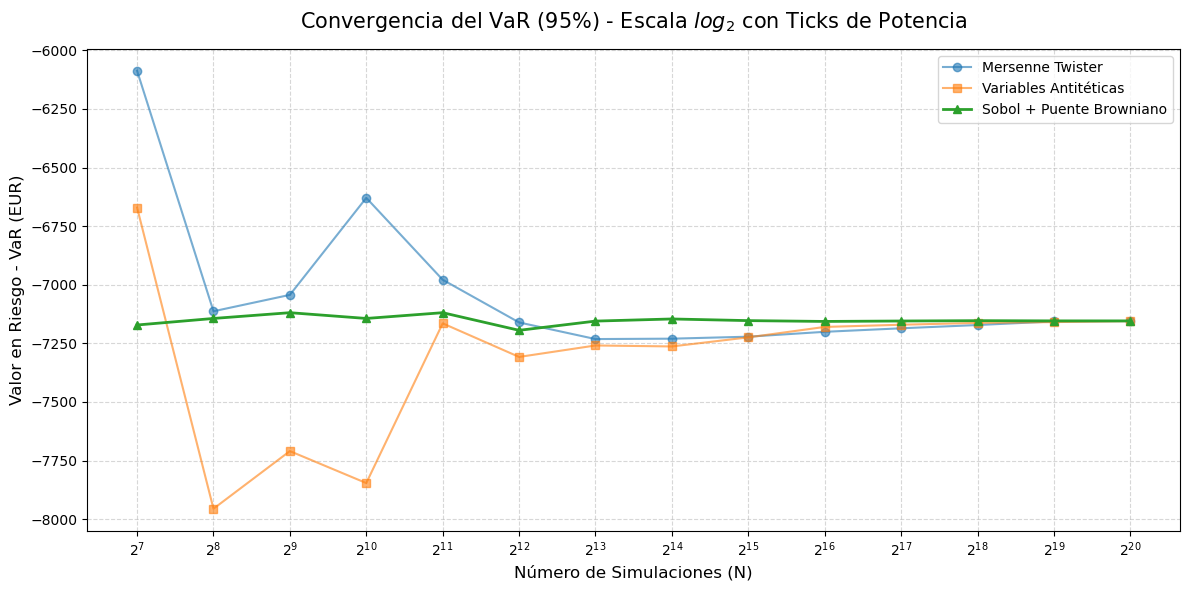

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# Ruta al archivo CSV
ruta_csv = "../graphics/convergencia_rng.csv" 

def plot_convergencia():
    try:
        df = pd.read_csv(ruta_csv)
        plt.figure(figsize=(12, 6))

        # Dibujar las series
        plt.plot(df['Simulaciones'], df['Mersenne_VaR95'], 
                 label='Mersenne Twister', color='#1f77b4', marker='o', alpha=0.6)
        plt.plot(df['Simulaciones'], df['Antithetic_VaR95'], 
                 label='Variables Antitéticas', color='#ff7f0e', marker='s', alpha=0.6)
        plt.plot(df['Simulaciones'], df['Sobol_VaR95'], 
                 label='Sobol + Puente Browniano', color='#2ca02c', marker='^', linewidth=2)

        # 1. Configurar escala logarítmica en base 2
        plt.xscale('log', base=2)

        # 2. Formatear los ticks para que aparezcan como 2^n
        # Usamos FuncFormatter para escribir el exponente en LaTeX
        plt.gca().xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'$2^{{{int(np.log2(x))}}}$'))

        # 3. Forzar que los ticks coincidan con las potencias de 2 presentes en los datos
        # Esto evita que Matplotlib ponga ticks intermedios feos
        powers_of_2 = 2**np.arange(np.floor(np.log2(df['Simulaciones'].min())), 
                                   np.ceil(np.log2(df['Simulaciones'].max())) + 1)
        plt.xticks(powers_of_2)

        # Formateo visual
        plt.title('Convergencia del VaR (95%) - Escala $log_2$ con Ticks de Potencia', fontsize=15, pad=15)
        plt.xlabel('Número de Simulaciones (N)', fontsize=12)
        plt.ylabel('Valor en Riesgo - VaR (EUR)', fontsize=12)
        
        plt.grid(True, which="both", linestyle='--', alpha=0.5)
        plt.legend(loc='best', fontsize=10)
        plt.tight_layout()

        plt.savefig("../graphics/grafica_convergencia_log2_ticks.png", dpi=300)
        print("Gráfica generada con éxito.")
        plt.show()

    except Exception as e:
        print(f"❌ Error: {e}")

if __name__ == "__main__":
    plot_convergencia()